In [1]:
import matplotlib.pyplot as plt
import matplotlib as mpl
plt.rc('text', usetex = True)

from ast import literal_eval as liteval 
import numpy as np
from scipy.optimize import curve_fit
import os
import math as m

import sys
sys.path.insert(0, os.getcwd().removesuffix("/lane"))
from file_utils import readData
sys.path.pop(0)

dirpath = "//media/ashwin/Expansion/ashwin_md/lane/Aug_Nov2025/Fd100/"
figpath = "/home/ashwin/Desktop/ashwin_md/LD/imgs/Nov2025/"

Text(0, 0.5, '$T^*_{\\textrm{eff}}$')

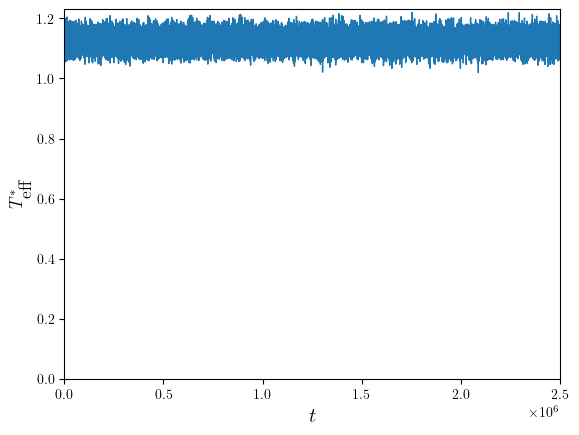

In [6]:
# Sample time series data

eq_steps = 1e7
dt = 5e-4

fpath = os.path.join(dirpath, "tau_5e-3", "thermo.dat")
[data, _] = readData(fpath, 1)

step = data[0]
temp = data[1]

time = [(i - eq_steps)*dt for i in step]

fig, ax = plt.subplots()
ax.plot(time, temp, lw = 1)

ax.set(xlim = (0e6, 2.5e6))
ax.set_ylim(bottom = 0)
ax.set_xlabel(r"$t$", fontsize = 15)
ax.set_ylabel(r"$T^*_{\textrm{eff}}$", fontsize = 13)


Time series statistics

Run average:  0.96471
Run std. dev.:  0.0517
[ 1.50550000e-03  2.13760395e-03 -3.90299341e+02]

R_sq for fit =  0.801


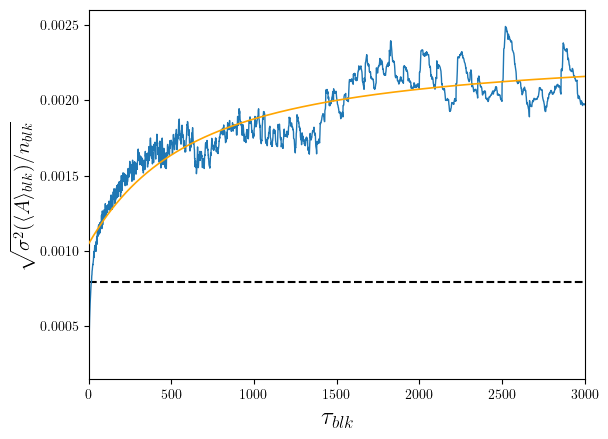

In [429]:
def func(x, a, b, c):
    return(a*np.arctan(b*(x - c)))

def computeSEM(A, max_blk_size, interval, scale):
    tau_run = len(A)
    run_avg = sum(A)/tau_run
    run_std = np.sqrt(sum([(i - run_avg)**2 for i in A])/(tau_run - 1))

    if(max_blk_size >= int(tau_run/2)):
        print("\nWarning! Maximum block size exceeds the permissible number {num}. Setting max_blk_size to {num}.".format(
            num = int(tau_run/2)))
        max_blk_size = int(tau_run/2)
    else:
        max_blk_size = int(max_blk_size)
        
    blk_sizes = range(1, max_blk_size + 1, interval)
    SEM = []

    for blk_size in blk_sizes:
        trim = int(tau_run%blk_size)
        new_A = A[0:(tau_run - trim)]

        Sum = 0
        n_blks = int(len(new_A)/blk_size)
        for i in range(0, n_blks):
            data_blk = new_A[i*blk_size:(i + 1)*blk_size]
            blk_avg = sum(data_blk)/blk_size
            Sum += (blk_avg - run_avg)**2

        blk_var = Sum/(n_blks - 1)
        SEM.append(np.sqrt(blk_var/n_blks))

    print("\nTime series statistics")
    print("\nRun average: ", round(run_avg, 5))
    print("Run std. dev.: ", round(run_std, 5))

    popt, _ = curve_fit(func, blk_sizes, SEM)
    print(popt)
    y_data = [func(i, popt[0], popt[1], popt[2]) for i in blk_sizes]

    SEM_avg = sum(SEM)/len(SEM)
    SS_tot = sum([(i - SEM_avg)**2 for i in SEM])
    SS_res = sum([(SEM[i] - y_data[i])**2 for i in range(len(SEM))])
    R2 = 1 - (SS_res/SS_tot)

    print("\nR_sq for fit = ", round(R2, 4))
    
    fig, ax = plt.subplots()

    if(scale == "lin"):
        ax.plot(blk_sizes, SEM, lw = 1, zorder = 2)
        ax.plot(blk_sizes, y_data, lw = 1.2, color = "orange", zorder = 3)
    elif(scale == "log"):
        ax.semilogx(blk_sizes, SEM, lw = 1, zorder = 2)
        ax.semilogx(blk_sizes, y_data, lw = 1.2, color = "orange", zorder = 3)

    ax.set_xlabel(r"$\tau_{blk}$", fontsize = 18)
    ax.set_ylabel(r"$\sqrt{\sigma^2(\langle A\rangle_{blk})/n_{blk}}$", fontsize = 15)
    ax.set(xlim = (0, max_blk_size))

    ax.axhline(y = 7.9e-4, xmin = 0, xmax = 1, linestyle = "--", color = "k", lw = 1.5, zorder = 1)

    # fig.savefig(os.path.join(figpath, "SEM_Fd100_tau_5e-3.png"), dpi = 500, bbox_inches = "tight")

fpath = os.path.join(dirpath, "tau_4e-2", "laneOrder_steady.dat")
[data, _] = readData(fpath, 1)
order = data[1]

computeSEM(order, max_blk_size = 3000, interval = 1, scale = "lin")